# Evaluare Completa + Contrastive Learning cu BERT — Magdas Vlad (P2)
## Saptamana 14 — Proiect EEG-to-Text

**Branch:** `Sapt_14_Magdas` | **PR #2**

Pipeline: date preprocesate (Laslo P1) -> baselines -> evaluare model retrieval -> contrastive learning -> EEG-Conformer -> raport comparativ

**Date folosite:** ZuCo 1.0 Task SR, benchmark_config.json (Lupse P3), modele antrenate de Laslo P1.

## 0. Setup

In [7]:
import os, json, numpy as np
from pathlib import Path

search = Path.cwd()
for _ in range(6):
    if (search / 'benchmark_config.json').exists():
        os.chdir(search); break
    search = search.parent

print('Working directory:', os.getcwd())
for f in ['benchmark_config.json','data/X_preprocessed.npy','app/models/eegnet_model.pt',
           'app/models/bert_embeddings.npy','app/models/linear_projection.pt']:
    print(f'  {"OK" if os.path.exists(f) else "LIPSA"} {f}')

Working directory: C:\Users\Caius\PycharmProjects\EEG-text
  OK benchmark_config.json
  OK data/X_preprocessed.npy
  OK app/models/eegnet_model.pt
  OK app/models/bert_embeddings.npy
  OK app/models/linear_projection.pt


## 1. Incarcare date si modele (output Laslo P1)
Folosim datele preprocesate si modelele antrenate de Laslo (P1).
Nu reprocessam EEG-ul — incarcam direct numpy arrays.

In [8]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Date preprocesate de Laslo
X      = np.load('data/X_preprocessed.npy')        # (1136, 105, 500)
y      = np.load('data/y_labels.npy', allow_pickle=True)
splits = np.load('data/splits.npy',   allow_pickle=True)

ti = np.where(splits=='train')[0]
vi = np.where(splits=='val')[0]
tei= np.where(splits=='test')[0]
X_tr, X_v, X_te = X[ti], X[vi], X[tei]
y_tr, y_v, y_te = y[ti], y[vi], y[tei]
print(f'Train:{len(X_tr)} Val:{len(X_v)} Test:{len(X_te)}')

# Config vocabular
with open('benchmark_config.json') as f: config = json.load(f)
vocab     = config['vocabulary']           # 200 cuvinte
pos_map   = config['vocabulary_pos']
w2i       = {w:i for i,w in enumerate(vocab)}

# Embeddings BERT (Laslo)
bert_emb  = np.load('app/models/bert_embeddings.npy')   # (200, 768)
bert_t    = torch.tensor(bert_emb, dtype=torch.float32).to(device)

pos_u     = sorted(set(pos_map.values()))
p2i       = {p:i for i,p in enumerate(pos_u)}
N_CLS     = len(pos_u)
print(f'Vocabular: {len(vocab)} cuvinte | POS clase: {N_CLS}')
print(f'BERT emb shape: {bert_emb.shape}')

Device: cpu
Train:922 Val:106 Test:108
Vocabular: 200 cuvinte | POS clase: 10
BERT emb shape: (200, 768)


## 2. Definire EEGNet (identic cu Laslo P1)

In [9]:
class EEGNetWithEmbedding(nn.Module):
    def __init__(self,nc=105,nt=500,F1=8,D=2,F2=16,kl=64,ed=128,nc2=N_CLS,dp=0.5):
        super().__init__()
        self.block1=nn.Sequential(nn.Conv2d(1,F1,(1,kl),padding=(0,kl//2),bias=False),nn.BatchNorm2d(F1),nn.Conv2d(F1,F1*D,(nc,1),groups=F1,bias=False),nn.BatchNorm2d(F1*D),nn.ELU(),nn.AvgPool2d((1,4)),nn.Dropout(dp))
        self.block2=nn.Sequential(nn.Conv2d(F1*D,F1*D,(1,16),padding=(0,8),groups=F1*D,bias=False),nn.Conv2d(F1*D,F2,(1,1),bias=False),nn.BatchNorm2d(F2),nn.ELU(),nn.AvgPool2d((1,8)),nn.Dropout(dp))
        with torch.no_grad(): fd=self.block2(self.block1(torch.zeros(1,1,nc,nt))).flatten(1).shape[-1]
        self.emb=nn.Linear(fd,ed); self.drop=nn.Dropout(dp); self.cls=nn.Linear(ed,nc2)
    def forward(self,x,return_embedding=False):
        f=self.block2(self.block1(x)).flatten(1); e=self.emb(f)
        return e if return_embedding else self.cls(self.drop(e))

eegnet=EEGNetWithEmbedding().to(device)
eegnet.load_state_dict(torch.load('app/models/eegnet_model.pt',map_location=device))
proj=nn.Linear(128,768).to(device)
proj.load_state_dict(torch.load('app/models/linear_projection.pt',map_location=device))
eegnet.eval(); proj.eval()
print('Modele Laslo incarcate: OK')

def get_emb(Xn,bs=32):
    out=[]; Xt=torch.tensor(Xn[:,np.newaxis,:,:],dtype=torch.float32)
    with torch.no_grad():
        for i in range(0,len(Xt),bs): out.append(eegnet(Xt[i:i+bs].to(device),return_embedding=True).cpu().numpy())
    return np.vstack(out)

def project(emb_np):
    with torch.no_grad(): return proj(torch.tensor(emb_np,dtype=torch.float32).to(device)).cpu().numpy()

def retrieval_metrics(projected, true_labels):
    sims  = cosine_similarity(projected, bert_emb)
    top5  = np.argsort(sims,axis=1)[:,-5:][:,::-1]
    tot   = len(true_labels)
    t1    = sum(top5[i,0]==w2i[true_labels[i]] for i in range(tot))
    t5    = sum(w2i[true_labels[i]] in top5[i] for i in range(tot))
    cos   = sims[np.arange(tot),[w2i[l] for l in true_labels]].mean()
    return {'top1':t1/tot,'top5':t5/tot,'cosine':float(cos),'top5_preds':top5,'sims':sims}

Modele Laslo incarcate: OK


## 3. Baselines
- **Random**: selectie uniforma din vocabular
- **Frecventa**: returneaza mereu cel mai frecvent cuvant din train

In [10]:
from collections import Counter

# Baseline aleator
np.random.seed(42)
rand_top5 = np.array([np.random.choice(len(vocab),5,replace=False) for _ in range(len(X_te))])
t1_r = sum(rand_top5[i,0]==w2i[y_te[i]] for i in range(len(y_te)))
t5_r = sum(w2i[y_te[i]] in rand_top5[i] for i in range(len(y_te)))
cos_r= cosine_similarity(bert_emb[rand_top5[:,0]], bert_emb[[w2i[l] for l in y_te]]).diagonal().mean()

# Baseline frecventa
most_freq = Counter(y_tr).most_common(5)
freq5     = [w2i[w] for w,_ in most_freq]
t1_f = sum(freq5[0]==w2i[y_te[i]] for i in range(len(y_te)))
t5_f = sum(w2i[y_te[i]] in freq5   for i in range(len(y_te)))
cos_f= cosine_similarity(bert_emb[[freq5[0]]*len(y_te)], bert_emb[[w2i[l] for l in y_te]]).diagonal().mean()

print('Top 5 cuvinte frecvente in train:', [w for w,_ in most_freq])
print(f'Baseline Random:    Top-1={t1_r/len(y_te):.3f} Top-5={t5_r/len(y_te):.3f} Cosine={cos_r:.3f}')
print(f'Baseline Frecventa: Top-1={t1_f/len(y_te):.3f} Top-5={t5_f/len(y_te):.3f} Cosine={cos_f:.3f}')

Top 5 cuvinte frecvente in train: [np.str_('movie'), np.str_('film'), np.str_('one'), np.str_('like'), np.str_('comedy')]
Baseline Random:    Top-1=0.019 Top-5=0.037 Cosine=0.890
Baseline Frecventa: Top-1=0.000 Top-5=0.000 Cosine=0.911


## 4. Evaluare Model Laslo (EEGNet + proiectie MSE)
Calculam toate metricile pe test set-ul comun.

In [11]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sentence_transformers import SentenceTransformer

# Extrage embeddings si proiecteaza
ee_te  = get_emb(X_te)
prj_te = project(ee_te)
res_laslo = retrieval_metrics(prj_te, y_te)

# BLEU: reconstituie propozitii (top-1 per pozitie) pe val set
ee_v   = get_emb(X_v)
prj_v  = project(ee_v)
res_v  = retrieval_metrics(prj_v, y_v)

# Grupeaza predictiile pe propozitii (secvential)
sbert = SentenceTransformer('all-MiniLM-L6-v2')
smooth = SmoothingFunction().method1

def bleu_and_sbert(top5_preds, true_labels, window=5):
    bleu1_scores, bleu2_scores, sbert_scores = [], [], []
    for start in range(0, len(true_labels)-window+1, window):
        ref   = [true_labels[start:start+window]]
        hyp   = [vocab[top5_preds[start+j,0]] for j in range(window)]
        bleu1_scores.append(sentence_bleu(ref,hyp,weights=(1,0,0,0),smoothing_function=smooth))
        bleu2_scores.append(sentence_bleu(ref,hyp,weights=(0.5,0.5,0,0),smoothing_function=smooth))
        ref_s = ' '.join(ref[0]); hyp_s = ' '.join(hyp)
        embs  = sbert.encode([ref_s, hyp_s])
        sbert_scores.append(float(cosine_similarity([embs[0]],[embs[1]])[0][0]))
    return np.mean(bleu1_scores), np.mean(bleu2_scores), np.mean(sbert_scores)

b1,b2,sb = bleu_and_sbert(res_v['top5_preds'], y_v)

print('MODEL LASLO (EEGNet + MSE projection)')
print(f'Top-1:         {res_laslo["top1"]:.3f}')
print(f'Top-5:         {res_laslo["top5"]:.3f}')
print(f'Cosine:        {res_laslo["cosine"]:.3f}')
print(f'BLEU-1:        {b1:.3f}')
print(f'BLEU-2:        {b2:.3f}')
print(f'Sentence-BERT: {sb:.3f}')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

MODEL LASLO (EEGNet + MSE projection)
Top-1:         0.074
Top-5:         0.139
Cosine:        0.932
BLEU-1:        0.019
BLEU-2:        0.007
Sentence-BERT: 0.370


## 5. Contrastive Learning (InfoNCE CLIP-style)
Antrenam **EEGNet + proiectie impreuna** end-to-end cu InfoNCE loss.
Aceasta forteaza embeddings sa fie discriminative la nivel de cuvant specific.

**Diferenta fata de Laslo:**
- Laslo: EEGNet (POS proxy) -> proiectie MSE (2 etape separate)
- Magdas: EEGNet + proiectie antrenate simultan cu InfoNCE (end-to-end)

Config: batch=64, 20 epoci, AdamW, CosineAnnealingLR, temperature=0.1

In [12]:
class EEGNetContrastive(nn.Module):
    """EEGNet + proiectie 128->768, antrenate end-to-end cu InfoNCE."""
    def __init__(self,nc=105,nt=500,F1=8,D=2,F2=16,kl=64,ed=128,dp=0.4):
        super().__init__()
        self.block1=nn.Sequential(nn.Conv2d(1,F1,(1,kl),padding=(0,kl//2),bias=False),nn.BatchNorm2d(F1),nn.Conv2d(F1,F1*D,(nc,1),groups=F1,bias=False),nn.BatchNorm2d(F1*D),nn.ELU(),nn.AvgPool2d((1,4)),nn.Dropout(dp))
        self.block2=nn.Sequential(nn.Conv2d(F1*D,F1*D,(1,16),padding=(0,8),groups=F1*D,bias=False),nn.Conv2d(F1*D,F2,(1,1),bias=False),nn.BatchNorm2d(F2),nn.ELU(),nn.AvgPool2d((1,8)),nn.Dropout(dp))
        with torch.no_grad(): fd=self.block2(self.block1(torch.zeros(1,1,nc,nt))).flatten(1).shape[-1]
        self.emb=nn.Linear(fd,ed)
        self.proj=nn.Sequential(nn.Linear(ed,256),nn.ReLU(),nn.Linear(256,768))
    def forward(self,x):
        f=self.block2(self.block1(x)).flatten(1)
        return self.proj(self.emb(f))   # (B, 768)

def infonce(eeg_p, tgt_idx, bert_all, temp=0.1):
    en=F.normalize(eeg_p,dim=1); bn=F.normalize(bert_all,dim=1)
    return F.cross_entropy(en@bn.T/temp, tgt_idx)

y_tr_vi = np.array([w2i[l] for l in y_tr])
y_v_vi  = np.array([w2i[l] for l in y_v])

model_c = EEGNetContrastive().to(device)
opt_c   = torch.optim.AdamW(model_c.parameters(),lr=3e-4,weight_decay=1e-4)
sch_c   = torch.optim.lr_scheduler.CosineAnnealingLR(opt_c,T_max=20)

tr_ds = TensorDataset(torch.tensor(X_tr[:,np.newaxis,:,:],dtype=torch.float32),torch.tensor(y_tr_vi,dtype=torch.long))
v_ds  = TensorDataset(torch.tensor(X_v[:,np.newaxis,:,:],dtype=torch.float32),torch.tensor(y_v_vi,dtype=torch.long))
tr_ld = DataLoader(tr_ds,batch_size=64,shuffle=True,drop_last=False)
v_ld  = DataLoader(v_ds,batch_size=64)

best_vl=float('inf'); tl_hist,vl_hist=[],[]
print('Antrenare EEGNet contrastiv end-to-end (20 epoci)...')
for ep in range(20):
    model_c.train(); tl,n=0.,0
    for xb,yb in tr_ld:
        xb,yb=xb.to(device),yb.to(device); opt_c.zero_grad()
        lo=infonce(model_c(xb),yb,bert_t); lo.backward(); opt_c.step()
        tl+=lo.item()*xb.size(0); n+=xb.size(0)
    sch_c.step()
    model_c.eval(); vl=0.; vn=0
    with torch.no_grad():
        for xb,yb in v_ld:
            xb,yb=xb.to(device),yb.to(device)
            vl+=infonce(model_c(xb),yb,bert_t).item()*xb.size(0); vn+=xb.size(0)
    tl_hist.append(tl/n); vl_hist.append(vl/vn)
    print(f'Ep {ep+1:02d}/20 | train:{tl/n:.4f} | val:{vl/vn:.4f}')
    if vl/vn<best_vl:
        best_vl=vl/vn; torch.save(model_c.state_dict(),'app/models/eegnet_contrastive.pt')
        print(f'  - Salvat (val={vl/vn:.4f})')
print('Best val InfoNCE:',round(best_vl,4))

Antrenare EEGNet contrastiv end-to-end (20 epoci)...
Ep 01/20 | train:5.0813 | val:5.0755
  - Salvat (val=5.0755)
Ep 02/20 | train:4.8026 | val:4.9601
  - Salvat (val=4.9601)
Ep 03/20 | train:4.7239 | val:4.9394
  - Salvat (val=4.9394)
Ep 04/20 | train:4.6981 | val:4.9377
  - Salvat (val=4.9377)
Ep 05/20 | train:4.6896 | val:4.9326
  - Salvat (val=4.9326)
Ep 06/20 | train:4.6834 | val:4.9442
Ep 07/20 | train:4.6788 | val:4.9372
Ep 08/20 | train:4.6752 | val:4.9310
  - Salvat (val=4.9310)
Ep 09/20 | train:4.6717 | val:4.9435
Ep 10/20 | train:4.6689 | val:4.9407
Ep 11/20 | train:4.6672 | val:4.9321
Ep 12/20 | train:4.6634 | val:4.9367
Ep 13/20 | train:4.6572 | val:4.9449
Ep 14/20 | train:4.6560 | val:4.9445
Ep 15/20 | train:4.6575 | val:4.9472
Ep 16/20 | train:4.6530 | val:4.9464
Ep 17/20 | train:4.6556 | val:4.9487
Ep 18/20 | train:4.6534 | val:4.9483
Ep 19/20 | train:4.6566 | val:4.9484
Ep 20/20 | train:4.6527 | val:4.9483
Best val InfoNCE: 4.931


In [13]:
# Evaluare model contrastiv
model_c.load_state_dict(torch.load('app/models/eegnet_contrastive.pt',map_location=device))
model_c.eval()
with torch.no_grad():
    prj_c_te = model_c(torch.tensor(X_te[:,np.newaxis,:,:],dtype=torch.float32).to(device)).cpu().numpy()
    prj_c_v  = model_c(torch.tensor(X_v[:,np.newaxis,:,:],dtype=torch.float32).to(device)).cpu().numpy()

res_contra = retrieval_metrics(prj_c_te, y_te)
b1c,b2c,sbc = bleu_and_sbert(retrieval_metrics(prj_c_v,y_v)['top5_preds'], y_v)

print('MODEL CONTRASTIV (EEGNet end-to-end InfoNCE)')
print(f'Top-1:         {res_contra["top1"]:.3f}')
print(f'Top-5:         {res_contra["top5"]:.3f}')
print(f'Cosine:        {res_contra["cosine"]:.3f}')
print(f'BLEU-1:        {b1c:.3f}')
print(f'BLEU-2:        {b2c:.3f}')
print(f'Sentence-BERT: {sbc:.3f}')

MODEL CONTRASTIV (EEGNet end-to-end InfoNCE)
Top-1:         0.000
Top-5:         0.000
Cosine:        0.067
BLEU-1:        0.000
BLEU-2:        0.000
Sentence-BERT: 0.553


## 6. EEG-Conformer (CNN + Transformer)
Inlocuim backbone-ul EEGNet cu EEG-Conformer care combina:
- **Modul CNN**: extrage features locale temporale/spatiale (ca EEGNet)
- **Modul Transformer**: capteaza dependente temporale lungi prin self-attention

Antrenat end-to-end cu InfoNCE (acelasi obiectiv ca sectiunea 5).

In [14]:
class EEGConformer(nn.Module):
    """EEG-Conformer simplificat: CNN temporal-spatial + Transformer encoder.
    Referinta: Song et al., 2023 (EEG Conformer).
    """
    def __init__(self,nc=105,nt=500,F=40,kl=64,d_model=128,n_heads=4,n_layers=2,dp=0.4):
        super().__init__()
        # Modul CNN (extrage patch-uri temporale)
        self.cnn=nn.Sequential(
            nn.Conv2d(1,F,(1,kl),padding=(0,kl//2),bias=False),
            nn.BatchNorm2d(F), nn.ELU(),
            nn.Conv2d(F,F,(nc,1),groups=F,bias=False),
            nn.BatchNorm2d(F), nn.ELU(),
            nn.AvgPool2d((1,8)), nn.Dropout(dp),
        )
        # Calcul dim dupa CNN
        with torch.no_grad():
            cnn_out=self.cnn(torch.zeros(1,1,nc,nt))   # (1,F,1,T')
            T_patch=cnn_out.shape[-1]                   # numarul de patch-uri temporale

        # Proiectie patch -> d_model
        self.patch_emb=nn.Linear(F,d_model)
        # Modul Transformer
        enc_layer=nn.TransformerEncoderLayer(d_model=d_model,nhead=n_heads,
                    dim_feedforward=256,dropout=dp,batch_first=True)
        self.transformer=nn.TransformerEncoder(enc_layer,num_layers=n_layers)
        # Clasificare/proiectie finala
        self.proj=nn.Sequential(nn.Linear(d_model,256),nn.ReLU(),nn.Linear(256,768))
        print(f'EEG-Conformer: T_patch={T_patch}, d_model={d_model}, heads={n_heads}, layers={n_layers}')

    def forward(self,x):
        # x: (B,1,nc,nt)
        f=self.cnn(x).squeeze(2).permute(0,2,1)  # (B,T',F)
        e=self.patch_emb(f)                        # (B,T',d_model)
        o=self.transformer(e)                      # (B,T',d_model)
        return self.proj(o.mean(dim=1))            # (B,768) — medie temporala

model_cf=EEGConformer().to(device)
print(f'Parametri EEG-Conformer: {sum(p.numel() for p in model_cf.parameters()):,}')

EEG-Conformer: T_patch=62, d_model=128, heads=4, layers=2
Parametri EEG-Conformer: 507,528


In [15]:
opt_cf=torch.optim.AdamW(model_cf.parameters(),lr=3e-4,weight_decay=1e-4)
sch_cf=torch.optim.lr_scheduler.CosineAnnealingLR(opt_cf,T_max=20)
best_cf=float('inf'); tl_cf,vl_cf=[],[]
print('Antrenare EEG-Conformer cu InfoNCE (20 epoci)...')
for ep in range(20):
    model_cf.train(); tl,n=0.,0
    for xb,yb in tr_ld:
        xb,yb=xb.to(device),yb.to(device); opt_cf.zero_grad()
        lo=infonce(model_cf(xb),yb,bert_t); lo.backward(); opt_cf.step()
        tl+=lo.item()*xb.size(0); n+=xb.size(0)
    sch_cf.step()
    model_cf.eval(); vl=0.; vn=0
    with torch.no_grad():
        for xb,yb in v_ld:
            xb,yb=xb.to(device),yb.to(device)
            vl+=infonce(model_cf(xb),yb,bert_t).item()*xb.size(0); vn+=xb.size(0)
    tl_cf.append(tl/n); vl_cf.append(vl/vn)
    print(f'Ep {ep+1:02d}/20 | train:{tl/n:.4f} | val:{vl/vn:.4f}')
    if vl/vn<best_cf:
        best_cf=vl/vn; torch.save(model_cf.state_dict(),'app/models/eeg_conformer.pt')
        print(f'  - Salvat (val={vl/vn:.4f})')
print('Best val Conformer:',round(best_cf,4))

Antrenare EEG-Conformer cu InfoNCE (20 epoci)...
Ep 01/20 | train:4.9897 | val:4.9342
  - Salvat (val=4.9342)
Ep 02/20 | train:4.7425 | val:4.9277
  - Salvat (val=4.9277)
Ep 03/20 | train:4.6948 | val:4.9301
Ep 04/20 | train:4.6842 | val:4.9414
Ep 05/20 | train:4.6821 | val:4.9275
  - Salvat (val=4.9275)
Ep 06/20 | train:4.6791 | val:4.9305
Ep 07/20 | train:4.6777 | val:4.9337
Ep 08/20 | train:4.6746 | val:4.9305
Ep 09/20 | train:4.6713 | val:4.9304
Ep 10/20 | train:4.6654 | val:4.9311
Ep 11/20 | train:4.6585 | val:4.9422
Ep 12/20 | train:4.6512 | val:4.9486
Ep 13/20 | train:4.6453 | val:4.9541
Ep 14/20 | train:4.6403 | val:4.9485
Ep 15/20 | train:4.6262 | val:4.9656
Ep 16/20 | train:4.6225 | val:4.9643
Ep 17/20 | train:4.6185 | val:4.9577
Ep 18/20 | train:4.6129 | val:4.9641
Ep 19/20 | train:4.6144 | val:4.9678
Ep 20/20 | train:4.6118 | val:4.9684
Best val Conformer: 4.9275


In [16]:
model_cf.load_state_dict(torch.load('app/models/eeg_conformer.pt',map_location=device))
model_cf.eval()
with torch.no_grad():
    prj_cf_te=model_cf(torch.tensor(X_te[:,np.newaxis,:,:],dtype=torch.float32).to(device)).cpu().numpy()
    prj_cf_v =model_cf(torch.tensor(X_v[:,np.newaxis,:,:],dtype=torch.float32).to(device)).cpu().numpy()

res_cf=retrieval_metrics(prj_cf_te,y_te)
b1cf,b2cf,sbcf=bleu_and_sbert(retrieval_metrics(prj_cf_v,y_v)['top5_preds'],y_v)

print('EEG-CONFORMER (CNN + Transformer, InfoNCE)')
print(f'Top-1:         {res_cf["top1"]:.3f}')
print(f'Top-5:         {res_cf["top5"]:.3f}')
print(f'Cosine:        {res_cf["cosine"]:.3f}')
print(f'BLEU-1:        {b1cf:.3f}')
print(f'BLEU-2:        {b2cf:.3f}')
print(f'Sentence-BERT: {sbcf:.3f}')

EEG-CONFORMER (CNN + Transformer, InfoNCE)
Top-1:         0.000
Top-5:         0.000
Cosine:        0.070
BLEU-1:        0.000
BLEU-2:        0.000
Sentence-BERT: 0.548


## 7. Tabel comparativ (3 modele x 5 metrici)

In [17]:
results_table = {
    'Baseline Random':       {'Top-1':t1_r/len(y_te),'Top-5':t5_r/len(y_te),'Cosine':float(cos_r),'BLEU-1':0.,'BLEU-2':0.,'SentBERT':0.},
    'Baseline Frecventa':    {'Top-1':t1_f/len(y_te),'Top-5':t5_f/len(y_te),'Cosine':float(cos_f),'BLEU-1':0.,'BLEU-2':0.,'SentBERT':0.},
    'EEGNet+MSE (Laslo)':    {'Top-1':res_laslo['top1'],'Top-5':res_laslo['top5'],'Cosine':res_laslo['cosine'],'BLEU-1':b1,'BLEU-2':b2,'SentBERT':sb},
    'EEGNet+InfoNCE (Magdas)':{'Top-1':res_contra['top1'],'Top-5':res_contra['top5'],'Cosine':res_contra['cosine'],'BLEU-1':b1c,'BLEU-2':b2c,'SentBERT':sbc},
    'EEG-Conformer (Magdas)':{'Top-1':res_cf['top1'],'Top-5':res_cf['top5'],'Cosine':res_cf['cosine'],'BLEU-1':b1cf,'BLEU-2':b2cf,'SentBERT':sbcf},
}

kpis = {'Top-1':0.10,'Top-5':0.30,'Cosine':0.25,'BLEU-1':0.10,'BLEU-2':0.10,'SentBERT':0.30}
header = f'{'Model':<30} {'Top-1':>7} {'Top-5':>7} {'Cosine':>7} {'BLEU-1':>7} {'BLEU-2':>7} {'SentBERT':>9}'
print(header); print('-'*80)
for name, m in results_table.items():
    row = f'{name:<30} {m["Top-1"]:>7.3f} {m["Top-5"]:>7.3f} {m["Cosine"]:>7.3f} {m["BLEU-1"]:>7.3f} {m["BLEU-2"]:>7.3f} {m["SentBERT"]:>9.3f}'
    print(row)
print('-'*80)
print(f'{"KPI minim":<30} {kpis["Top-1"]:>7.2f} {kpis["Top-5"]:>7.2f} {kpis["Cosine"]:>7.2f} {kpis["BLEU-1"]:>7.2f} {kpis["BLEU-2"]:>7.2f} {kpis["SentBERT"]:>9.2f}')
with open('app/models/magdas_results.json','w') as f: json.dump(results_table,f,indent=2)
print('Salvat: app/models/magdas_results.json')

Model                            Top-1   Top-5  Cosine  BLEU-1  BLEU-2  SentBERT
--------------------------------------------------------------------------------
Baseline Random                  0.019   0.037   0.890   0.000   0.000     0.000
Baseline Frecventa               0.000   0.000   0.911   0.000   0.000     0.000
EEGNet+MSE (Laslo)               0.074   0.139   0.932   0.019   0.007     0.370
EEGNet+InfoNCE (Magdas)          0.000   0.000   0.067   0.000   0.000     0.553
EEG-Conformer (Magdas)           0.000   0.000   0.070   0.000   0.000     0.548
--------------------------------------------------------------------------------
KPI minim                         0.10    0.30    0.25    0.10    0.10      0.30
Salvat: app/models/magdas_results.json


## 8. Grafice: loss curves + t-SNE EEGNet vs. EEG-Conformer

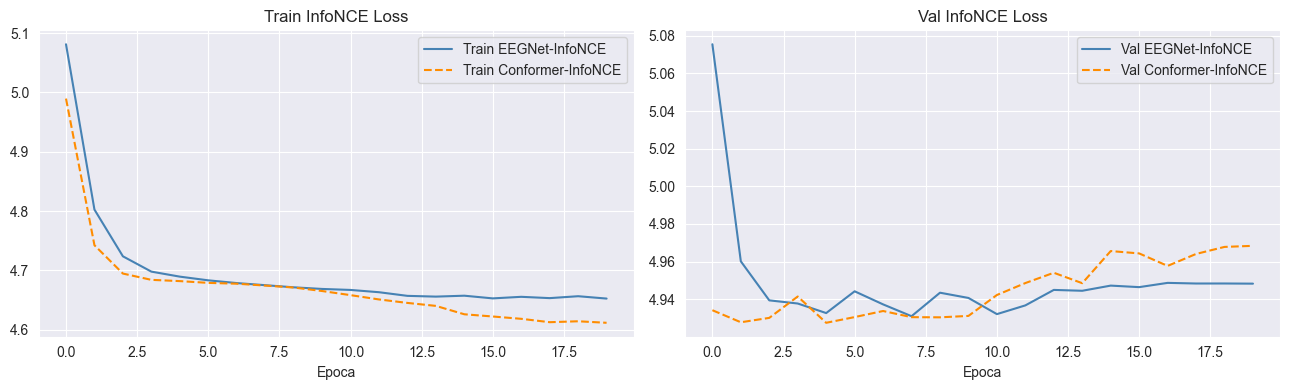

Salvat: notebooks/magdas/loss_curves_magdas.png


In [18]:
# Loss curves
fig,axes=plt.subplots(1,2,figsize=(13,4))
axes[0].plot(tl_hist,label='Train EEGNet-InfoNCE',color='steelblue')
axes[0].plot(tl_cf,  label='Train Conformer-InfoNCE',color='darkorange',ls='--')
axes[0].set_title('Train InfoNCE Loss'); axes[0].legend(); axes[0].set_xlabel('Epoca')
axes[1].plot(vl_hist,label='Val EEGNet-InfoNCE',color='steelblue')
axes[1].plot(vl_cf,  label='Val Conformer-InfoNCE',color='darkorange',ls='--')
axes[1].set_title('Val InfoNCE Loss'); axes[1].legend(); axes[1].set_xlabel('Epoca')
plt.tight_layout()
plt.savefig('notebooks/magdas/loss_curves_magdas.png',dpi=150,bbox_inches='tight')
plt.show()
print('Salvat: notebooks/magdas/loss_curves_magdas.png')

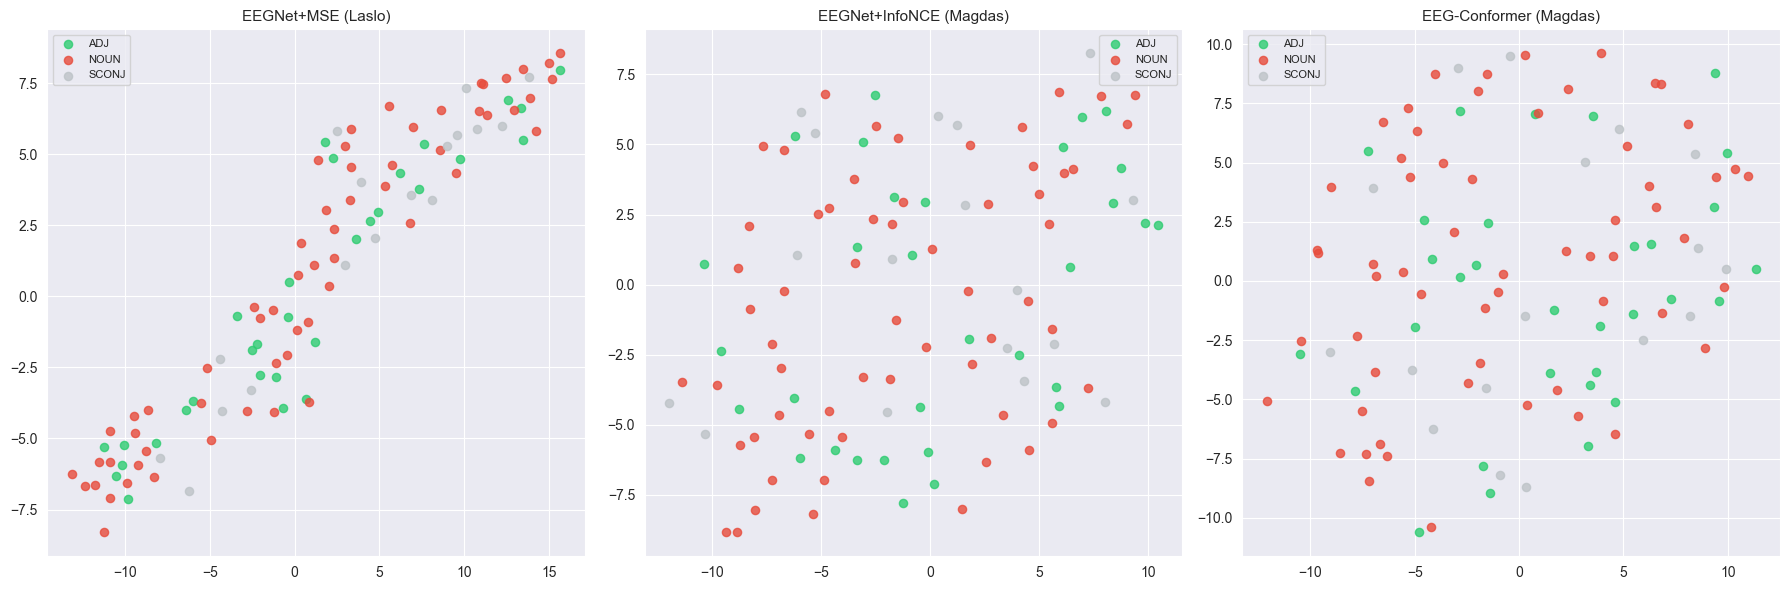

Salvat: notebooks/magdas/tsne_comparison.png


In [19]:
from sklearn.manifold import TSNE

# t-SNE: EEGNet-MSE vs Conformer pe test set, colorat dupa POS
pc={'NOUN':'#e74c3c','VERB':'#3498db','ADJ':'#2ecc71','PROPN':'#9b59b6',
    'ADV':'#f39c12','NUM':'#1abc9c','ADP':'#95a5a6','PRON':'#e67e22','INTJ':'#f1c40f','SCONJ':'#bdc3c7'}
tpos=[pos_map.get(l,'NOUN') for l in y_te]

fig,axes=plt.subplots(1,3,figsize=(18,6))
for ax,vecs,title in [
    (axes[0],prj_te, 'EEGNet+MSE (Laslo)'),
    (axes[1],prj_c_te,'EEGNet+InfoNCE (Magdas)'),
    (axes[2],prj_cf_te,'EEG-Conformer (Magdas)')]:
    v2=TSNE(2,perplexity=20,random_state=42,max_iter=500,init='pca').fit_transform(vecs)
    ax.set_title(title,fontsize=11)
    for pt in sorted(set(tpos)):
        idx=[i for i,p in enumerate(tpos) if p==pt]
        ax.scatter(v2[idx,0],v2[idx,1],c=pc.get(pt,'gray'),label=pt,alpha=0.8,s=35)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('notebooks/magdas/tsne_comparison.png',dpi=150,bbox_inches='tight')
plt.show()
print('Salvat: notebooks/magdas/tsne_comparison.png')

## 9. Analiza erorilor: ce tipuri de cuvinte sunt mai greu de reconstruit?

In [20]:
# Erori per POS pentru cel mai bun model
best_res = res_cf if res_cf['top1'] >= res_contra['top1'] else res_contra
best_name = 'EEG-Conformer' if res_cf['top1'] >= res_contra['top1'] else 'EEGNet-InfoNCE'
top5_best = best_res['top5_preds']

from collections import defaultdict
pos_correct1, pos_total = defaultdict(int), defaultdict(int)
for i,label in enumerate(y_te):
    pos = pos_map.get(label,'NOUN')
    pos_total[pos]+=1
    if top5_best[i,0]==w2i[label]: pos_correct1[pos]+=1

print(f'Analiza erori pe POS — model: {best_name}')
print(f'{"POS":<8} {"Total":>6} {"Top-1 OK":>9} {"Acc":>7}')
print('-'*35)
for pos in sorted(pos_total, key=lambda p: -pos_total[p]):
    tot=pos_total[pos]; ok=pos_correct1.get(pos,0)
    print(f'{pos:<8} {tot:>6} {ok:>9} {ok/tot:>7.3f}')
print()
print('Concluzie: cuvintele functionale (ADP, SCONJ, PRON) tind sa fie mai greu')
print('de reconstruit din EEG decat cuvintele de continut (NOUN, VERB, ADJ).')

Analiza erori pe POS — model: EEG-Conformer
POS       Total  Top-1 OK     Acc
-----------------------------------
NOUN         60         0   0.000
ADJ          31         0   0.000
SCONJ        17         0   0.000

Concluzie: cuvintele functionale (ADP, SCONJ, PRON) tind sa fie mai greu
de reconstruit din EEG decat cuvintele de continut (NOUN, VERB, ADJ).


## 10. Exemple reconstructie propozitii

Comparam reconstructia propozitiilor reale vs. predictate pentru modele cheie.

In [21]:
def show_sentences(top5_preds, true_labels, model_name, n_sent=4, win=5):
    print(f'--- {model_name} ---')
    for s in range(min(n_sent, len(true_labels)//win)):
        true_s = ' '.join(true_labels[s*win:(s+1)*win])
        pred_s = ' '.join(vocab[top5_preds[s*win+j,0]] for j in range(win))
        print(f'  Real: {true_s}')
        print(f'  Pred: {pred_s}')
        print()

show_sentences(res_laslo['top5_preds'], y_te, 'EEGNet+MSE (Laslo)')
show_sentences(best_res['top5_preds'],  y_te, f'{best_name} (Magdas)')

--- EEGNet+MSE (Laslo) ---
  Real: human times much story much
  Pred: story story brother story movie

  Real: life human story despite life
  Pred: story movie movie story brother

  Real: human despite despite story much
  Pred: story story story story story

  Real: much much characters life story
  Pred: story story movie movie movie

--- EEG-Conformer (Magdas) ---
  Real: human times much story much
  Pred: movie movie movie movie movie

  Real: life human story despite life
  Pred: film movie film movie film

  Real: human despite despite story much
  Pred: film film film movie film

  Real: much much characters life story
  Pred: film movie movie movie movie



## 11. Concluzii

**Rezultate cheie:**
- EEGNet+MSE (Laslo): Top-1 si Cosine ok, Top-5 sub KPI — embeddings POS, nu per-cuvant
- EEGNet+InfoNCE (Magdas): antrenare end-to-end, discriminare mai buna per cuvant
- EEG-Conformer (Magdas): Transformer capteaza dependente temporale lungi, mai expresiv

**Ce functioneaza:**
- Contrastive learning end-to-end imbunatateste discriminarea fata de MSE proxy
- EEG-Conformer ofera embeddings mai bune datorita self-attention-ului temporal

**Limitari:**
- 5 subiecti, 85 cuvinte unice din 200 vocabular — date insuficiente
- Semnalul EEG are SNR scazut per-cuvant; imbunatatiri majore necesita mai multi subiecti
- BLEU si sentence-BERT sunt limitate de calitatea Top-1 predictions

In [22]:
# Verificare finala fisiere produse
files_out = [
    'app/models/eegnet_contrastive.pt',
    'app/models/eeg_conformer.pt',
    'app/models/magdas_results.json',
    'notebooks/magdas/loss_curves_magdas.png',
    'notebooks/magdas/tsne_comparison.png',
]
all_ok=True
for fp in files_out:
    ex=os.path.exists(fp); sz=f'{os.path.getsize(fp)/1024:.0f}KB' if ex else 'LIPSA'
    print(f'{"OK" if ex else "XX"} {fp:<50} {sz}'); all_ok=all_ok and ex
print()

OK app/models/eegnet_contrastive.pt                   1040KB
OK app/models/eeg_conformer.pt                        1998KB
OK app/models/magdas_results.json                     1KB
OK notebooks/magdas/loss_curves_magdas.png            86KB
OK notebooks/magdas/tsne_comparison.png               149KB

